<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">

# CAD Similarity Search Using HOOPS Embeddings

This notebook demonstrates how to query a pre-built FAISS index with a CAD file and
retrieve the most geometrically similar parts from a large indexed dataset.

**Prerequisites:** A FAISS index built with
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb).

## Workflow

1. Configure paths to the model checkpoint and FAISS index.
2. Register the model and load the index into `CADSearch`.
3. Embed a query CAD file and search for similar parts.

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.1.0  (build: ed23c844 2026-06-12T14:14:13Z)
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-06-12T10:38:16Z)
  Conversion    : hoops-converter      26.1.1  (build: 00dc9f6 2026-06-12T10:22:46Z)
  Insights      : hoops-web-viewer     26.1.1  (build: d30058f 2026-06-12T10:22:25Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


## 1. Configure paths

Set the path to the pre-trained model checkpoint and the FAISS index. Both live
under `packages/` — one level above this notebook.

In [2]:
from hoops_ai.ml.embeddings import HOOPSEmbeddings, Embedding, EmbeddingBatch
import pathlib

packages_dir = pathlib.Path.cwd().parent.joinpath("packages")

pretrained_model = packages_dir.joinpath("trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt")

### Pre-built TMCAD index

A pre-indexed FAISS store for the TMCAD dataset is available for download at <https://transfer.techsoft3d.com/link/eiZk3koBNP4C0m6gQzRcXj> ask the password for downloading to your Tech Soft 3D contact person, or you can build
your own with [`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb).

Place the downloaded folder contents under `packages/vectorstores/tmcad/`.

In [3]:
indexed_database = packages_dir.joinpath("vectorstores","tmcad","TMCAD_SIGNAL.faiss")

if not indexed_database.exists():
    sys.exit("TMCAD_SIGNAL.faiss file is required. See section Indexed database with TMCAD dataset")

## 2. Register the model

The pre-trained SIGNAL model is used here. To use a custom model trained on your own
data, replace `pretrained_model` with the path to your checkpoint (see
[`demo_HOOPS_EMBEDDINGS_training.ipynb`](./demo_HOOPS_EMBEDDINGS_training.ipynb)).

In [4]:
# HOOPS AI release 1.1
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pretrained_model)
)

print(HOOPSEmbeddings.list_available_models())

['HOOPS Embeddings SIGNAL preview']


In [5]:
embedder = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview")

print(f"Using model: {embedder.model_name} with dimension: {embedder.embedding_dim}")

Successfully loaded model from checkpoint: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt
Using model: HOOPS Embeddings SIGNAL preview with dimension: 2048


c:\Users\LuisSalazar.LY-LS-LEGION\Documents\hoops-ai-packages-test\.venv\Lib\site-packages\pytorch_lightning\utilities\parsing.py:136: pytorch_lightning save_hyperparameters: frame introspection failed. Nuitka-compiled frames have empty locals, which breaks PL's collect_init_args. Pass an explicit dict to save_hyperparameters() for correct hparams under Nuitka.


## 3. Load the FAISS index

Deserialize the index into a `CADSearch` instance. Once loaded, all similarity
queries run entirely in memory — no re-encoding needed.

In [6]:
from hoops_ai.ml import CADSearch

loaded_searcher = CADSearch(shape_model=embedder)

embeddingBatch = loaded_searcher.load_shape_index(path=str(indexed_database))

print(f"Source {embeddingBatch.model}")
print(f"Loaded {len(embeddingBatch.ids)} part embeddings (dim={embeddingBatch.values.shape[1]}).")


Source CUSTOM:HOOPS Embeddings SIGNAL preview
Loaded 39736 part embeddings (dim=2048).


<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 30%;">

In [7]:
from hoops_ai.insights import DatasetViewer

ds_viewer = DatasetViewer([], [], [], reference_dir=packages_dir.joinpath("vectorstores","tmcad","images_tmcad"))

## 4. Similarity search

The cells below query the index with demo CAD files from `packages/vectorstores/tmcad/queries_for_demo/`
and display the top-K results visually. Images are for reference only — the
embedding model operates entirely on B-rep geometry, not on rendered pixels.

### Load query files

In [8]:
from hoops_ai.storage import CADFileRetriever, LocalStorageProvider
import pathlib
demo_cad_files_folder = packages_dir.joinpath("vectorstores","tmcad","queries_for_demo")

if not demo_cad_files_folder.exists():
    sys.exit("Demo Files folder is required. See section Indexed database with TMCAD dataset")

retriever = CADFileRetriever(storage_provider=LocalStorageProvider(directory_path=demo_cad_files_folder), formats=[".stp", ".step", ".iges", ".igs"])

cad_files = retriever.get_file_list()
print(len(cad_files), "files found." )

20 files found.


### Option A — embed then search (two calls)

Calling `embed_shape` and `search_by_embedding` separately exposes the per-step
timing. B-rep encoding dominates; the vector search over 38 K parts is near-instant.

In [9]:
import time

t0 = time.perf_counter()

query_file = str(cad_files[0])
query_embeddings = embedder.embed_shape(query_file)[0]
print(query_embeddings.values)
elapsed = time.perf_counter() - t0
print(f"Computing embeddings for single file took {elapsed:.3f} s")


[ 0.00861762 -0.11074723  0.09326995 ... -0.16870733 -0.04412446
  0.08299841]
Computing embeddings for single file took 5.275 s


Search similar files in dataset of 39736 files took 0.015 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


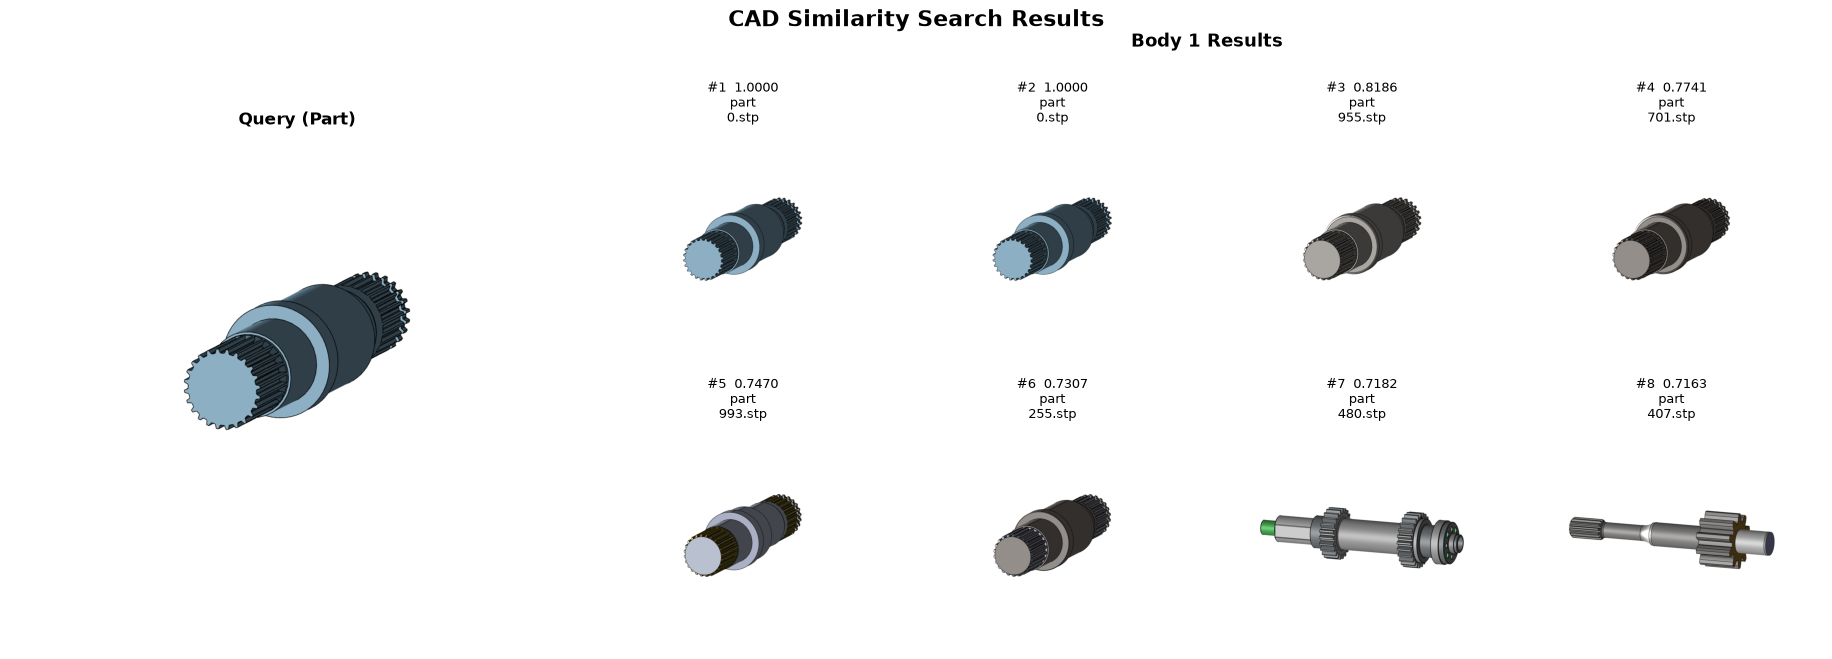

In [10]:
t0 = time.perf_counter()
hits = loaded_searcher.search_by_embedding(query_embeddings, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

### Option B — search directly from a file (single call)

`search_by_shape` combines encoding and search in one call. Use this when
you don't need the intermediate embedding or per-step timing.

Data Prep + Search similar files in dataset of 39736 files took 1.742 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


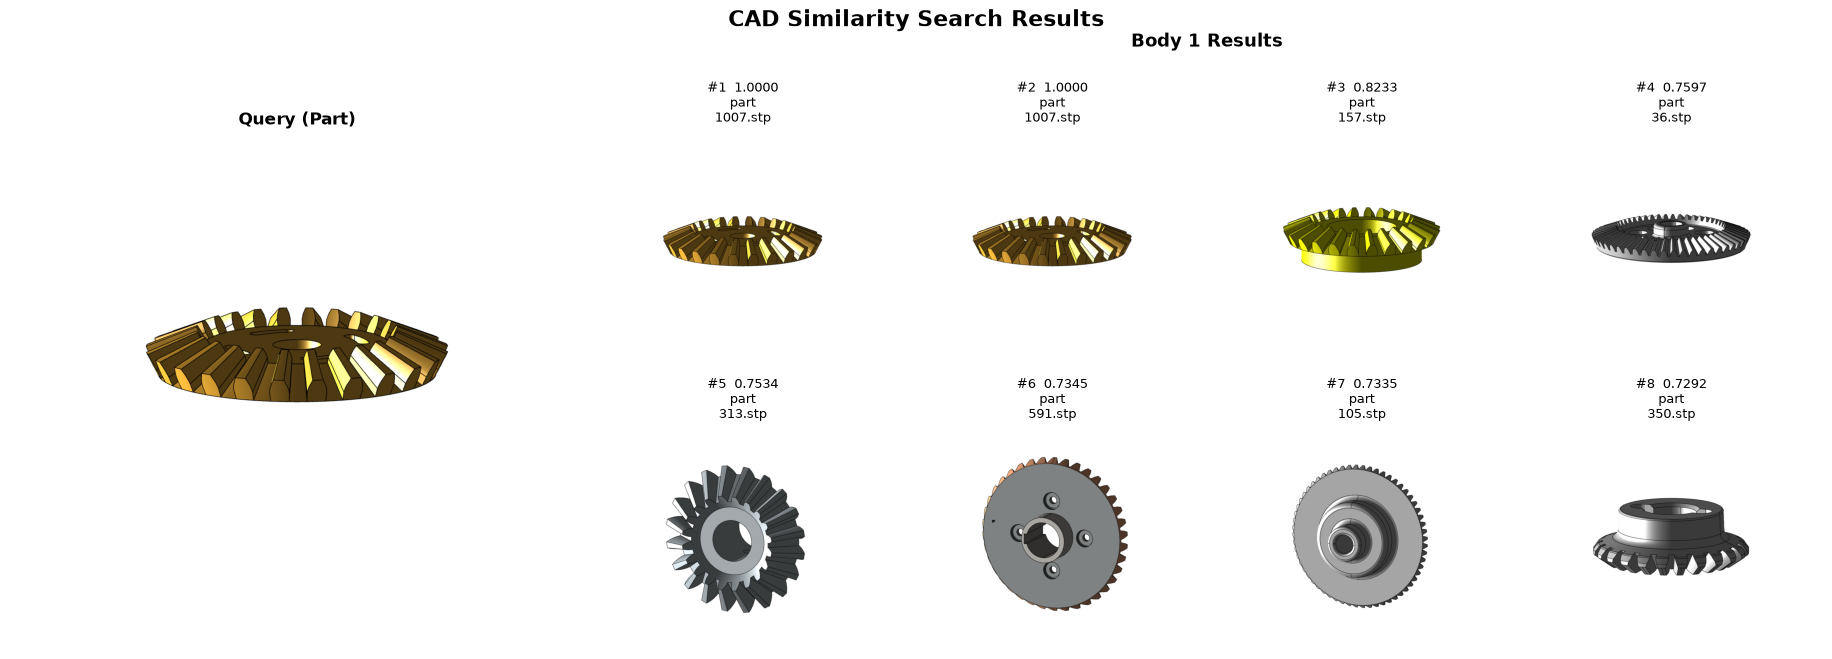

In [11]:

query_file = str(cad_files[3])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 0.165 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


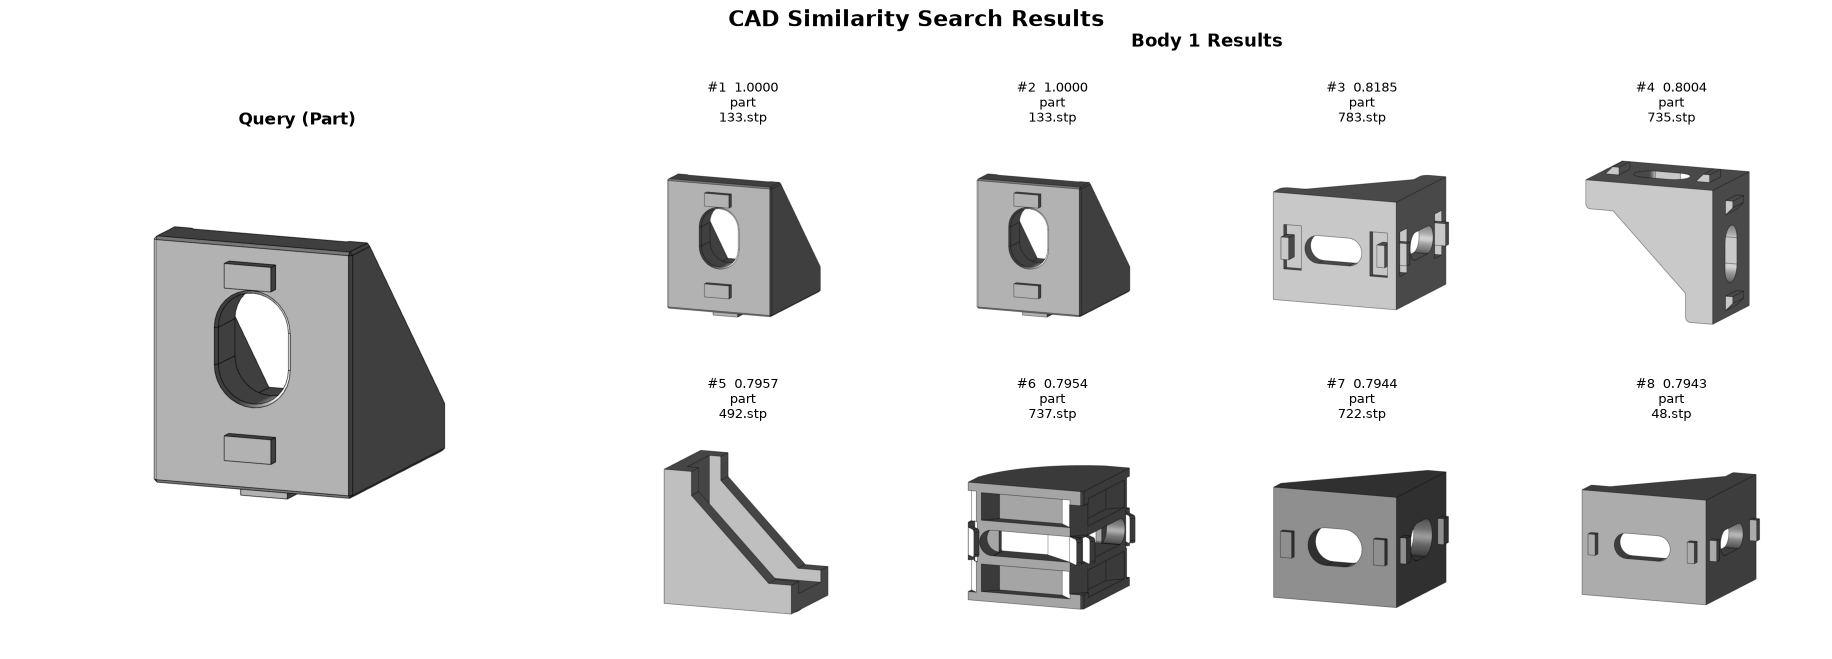

In [12]:
query_file = str(cad_files[4])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 40.299 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


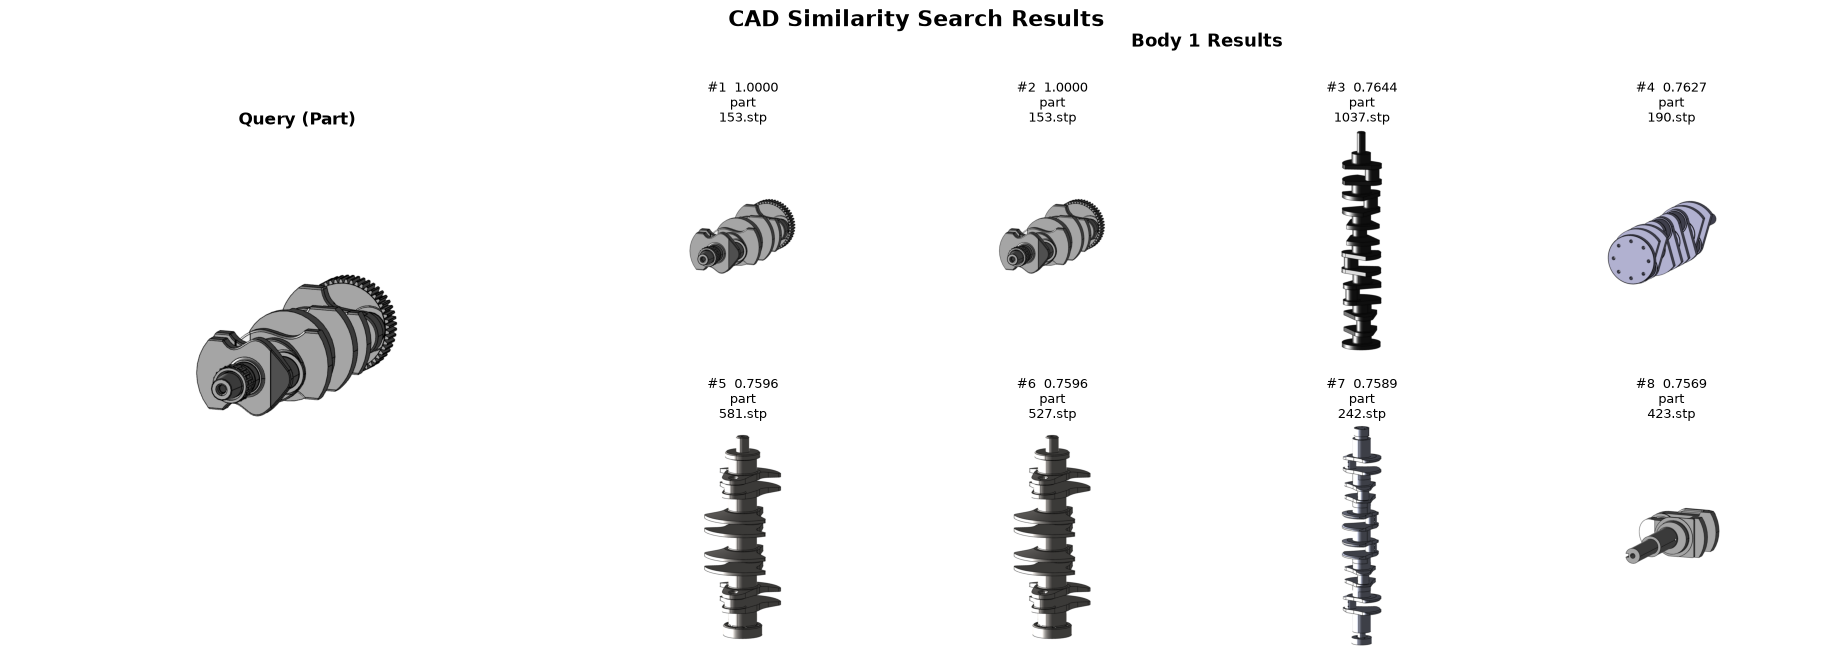

In [14]:
query_file = str(cad_files[6])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 1.587 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


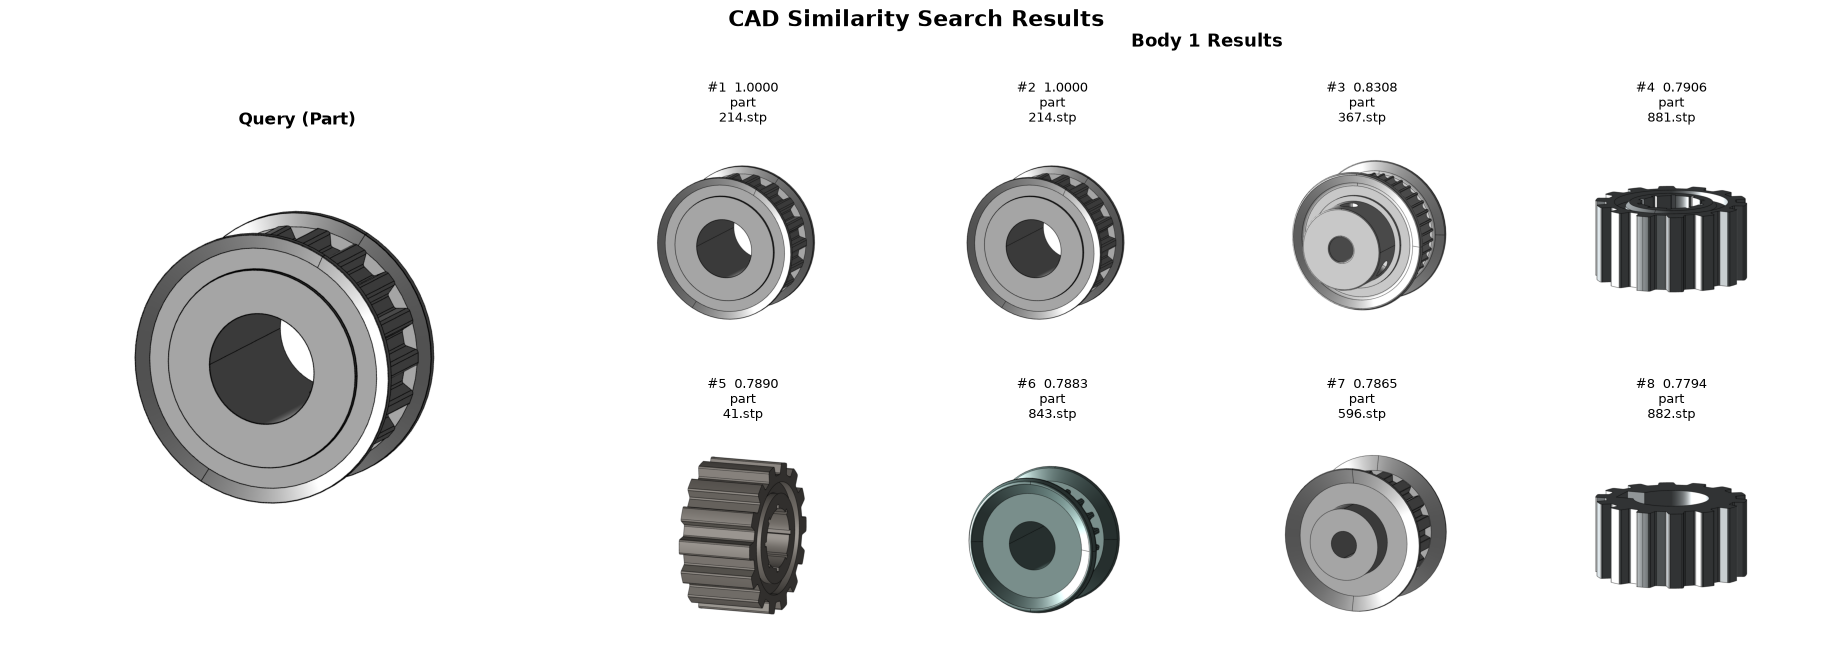

In [16]:
query_file = str(cad_files[8])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 0.499 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


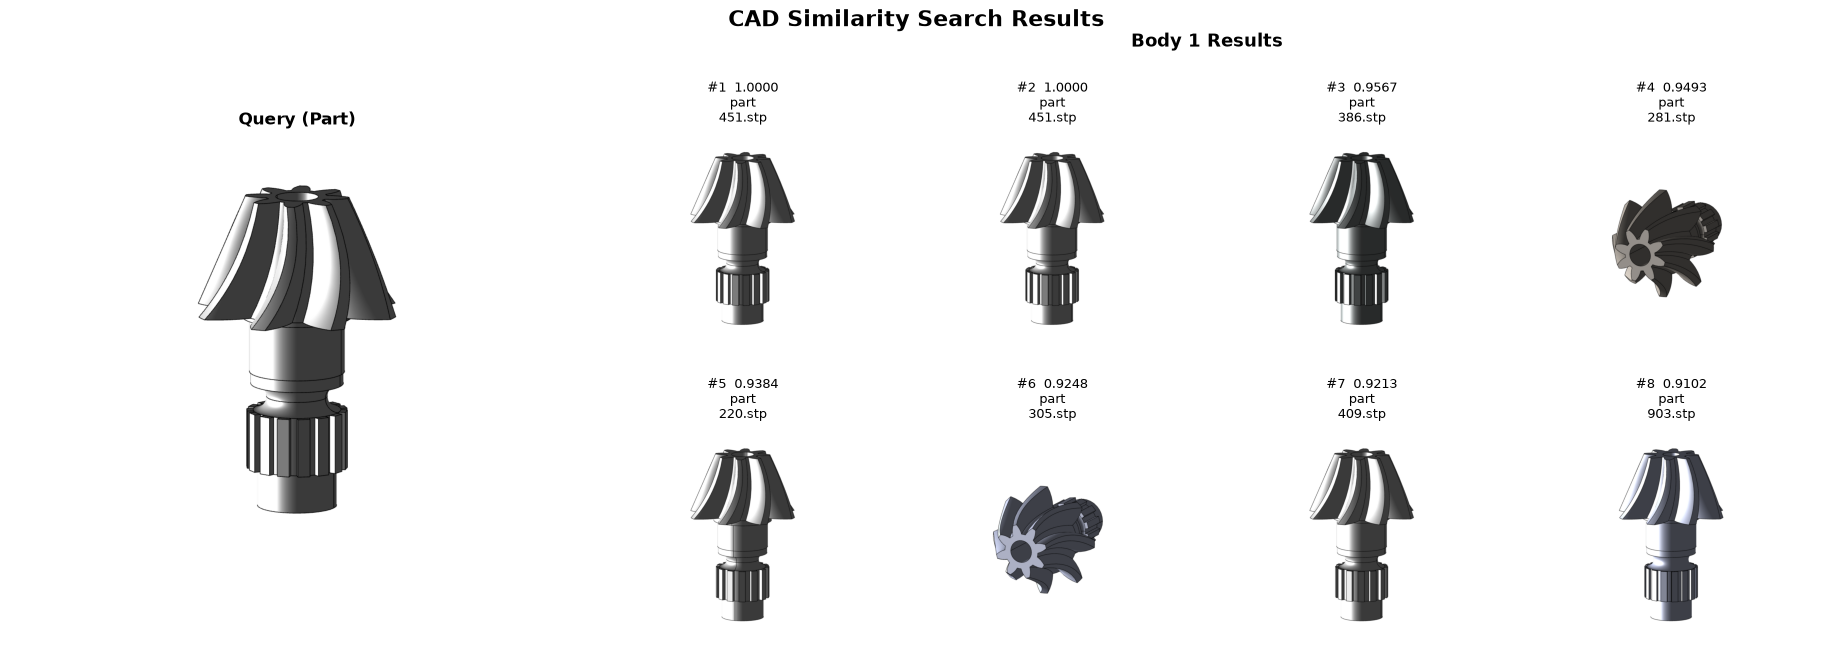

In [18]:
query_file = str(cad_files[10])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 0.373 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


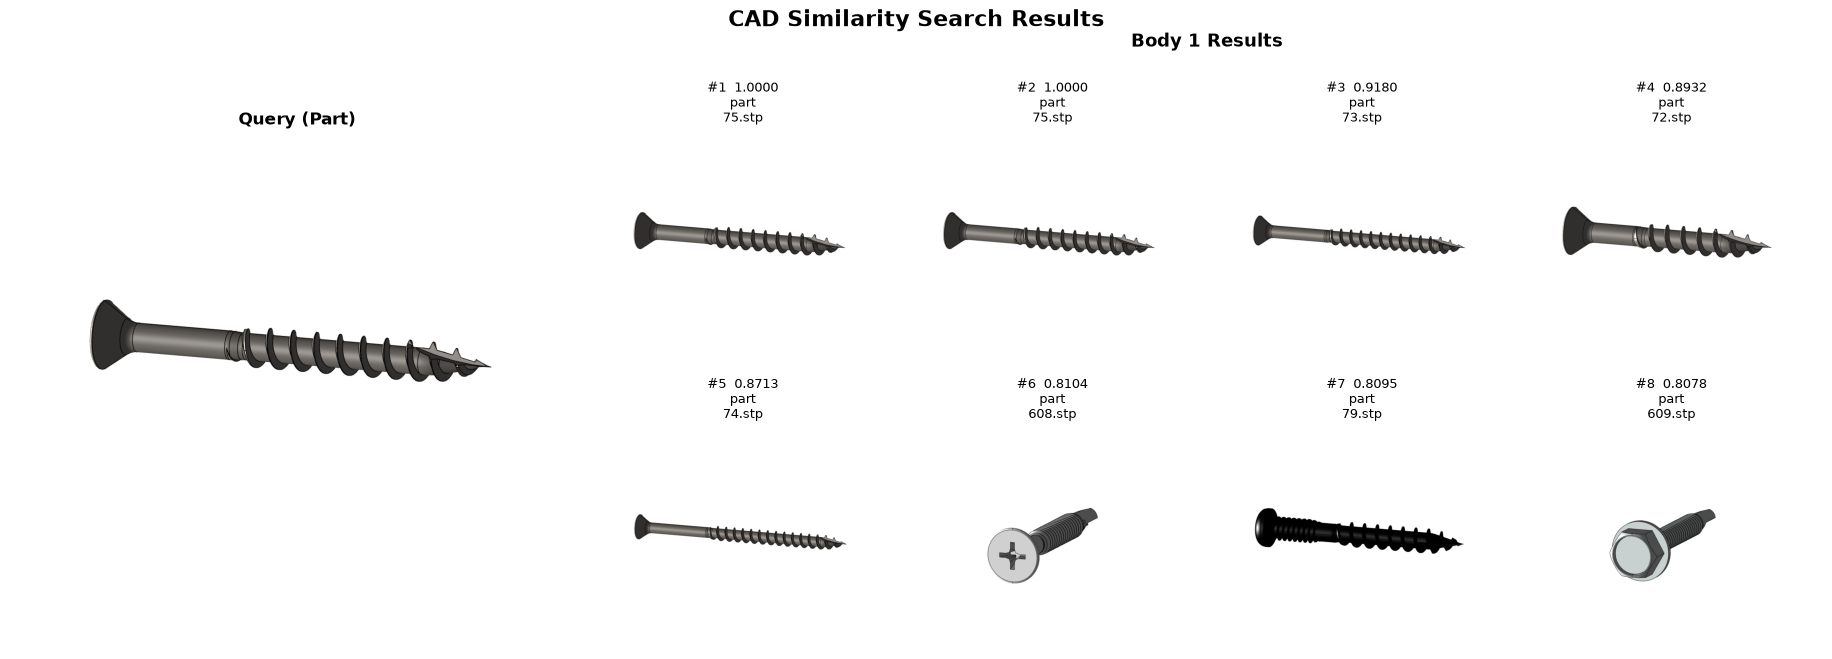

In [21]:
query_file = str(cad_files[13])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 0.085 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


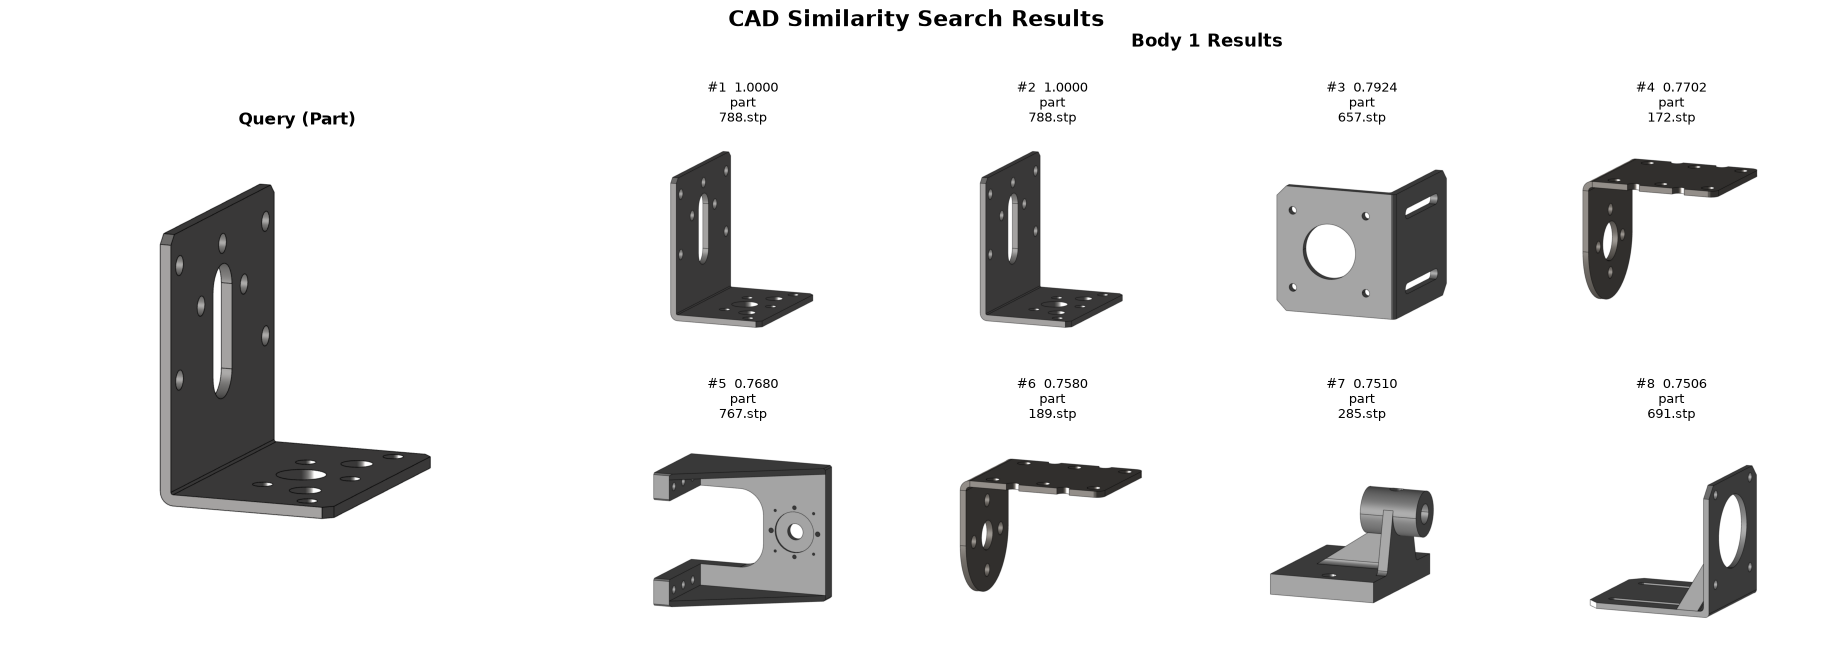

In [22]:
query_file = str(cad_files[14])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 1.292 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


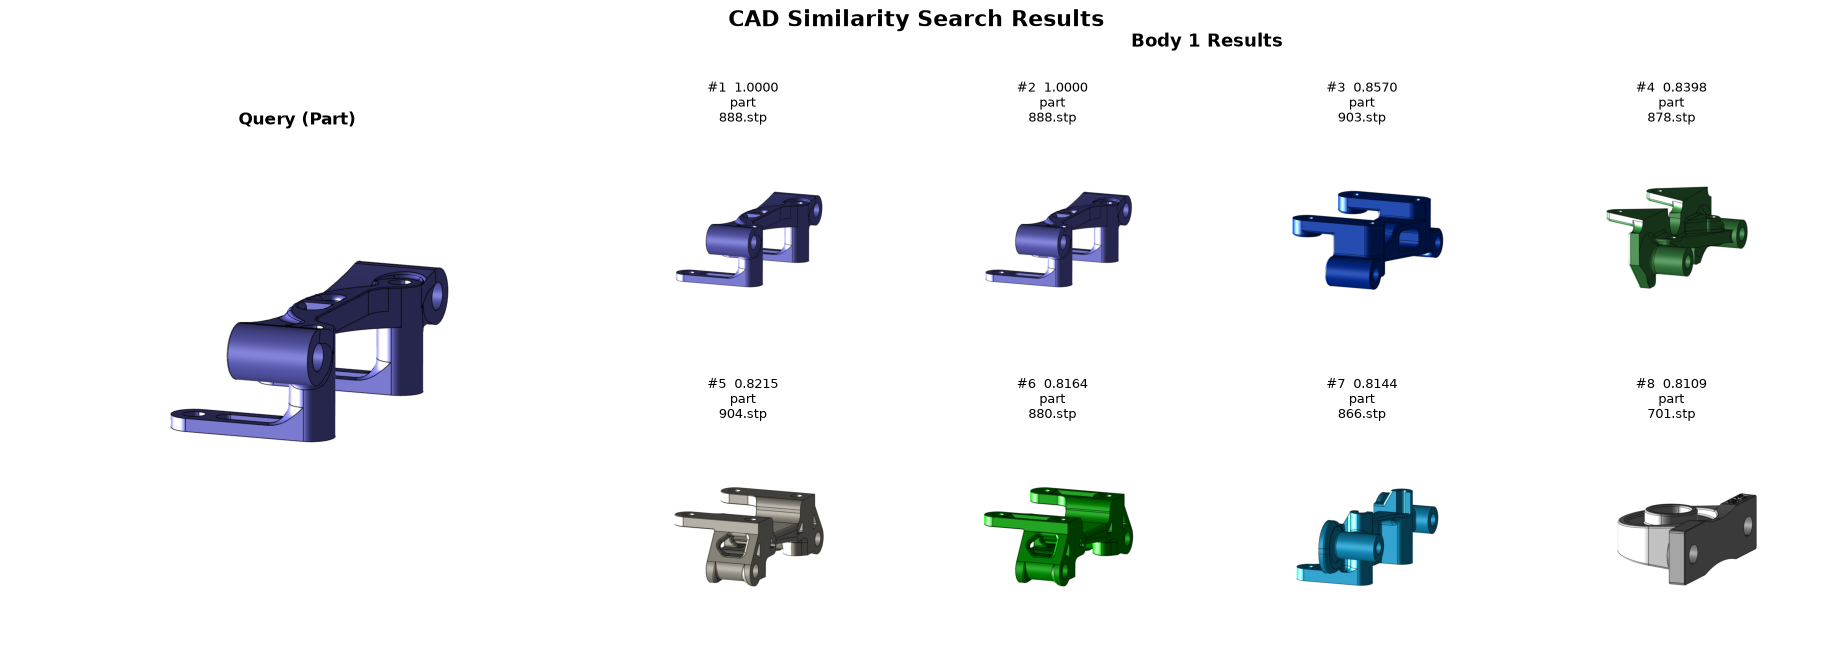

In [23]:
query_file = str(cad_files[15])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 2.426 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


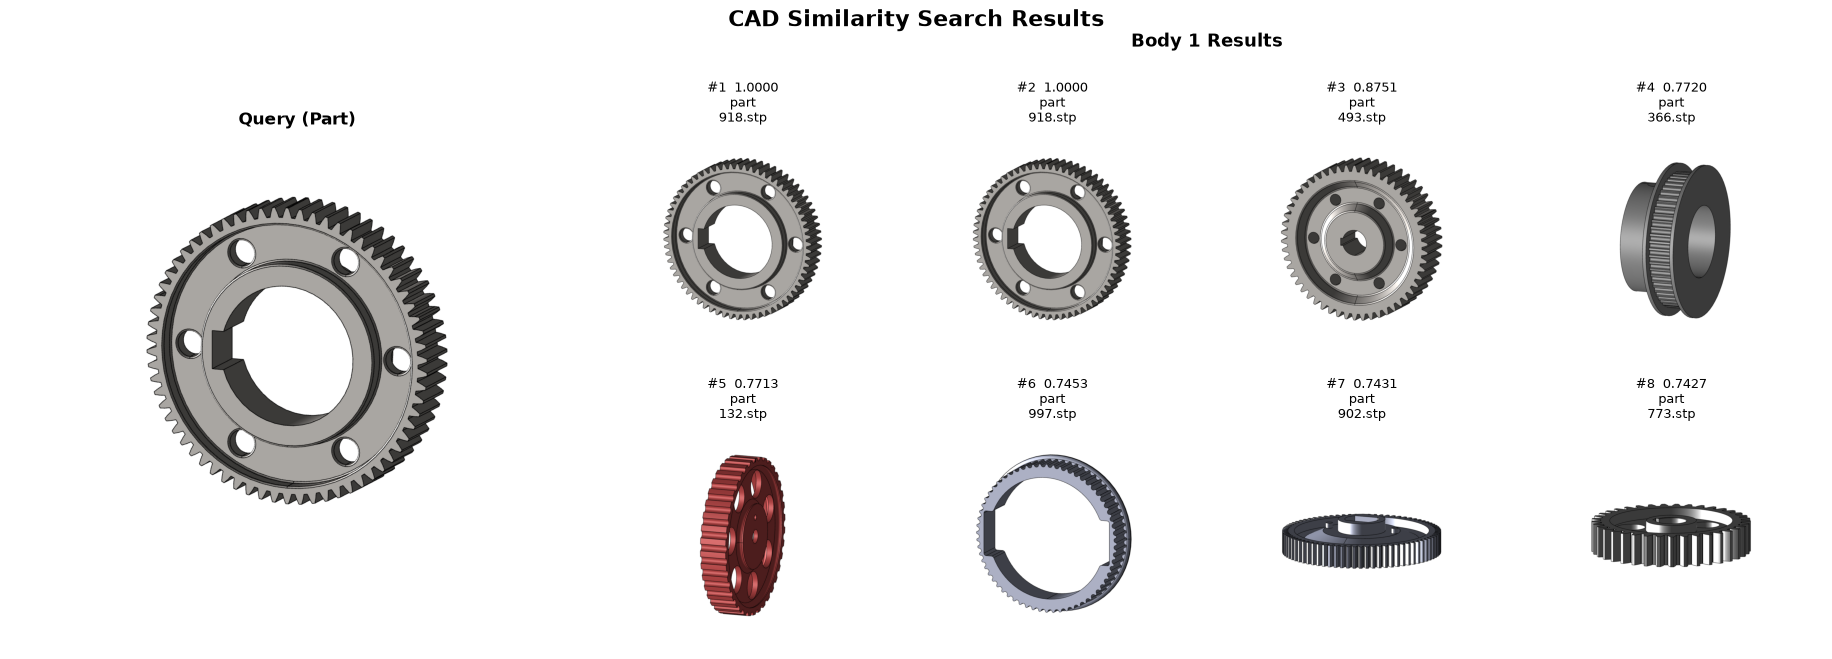

In [24]:
query_file = str(cad_files[16])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 2.533 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


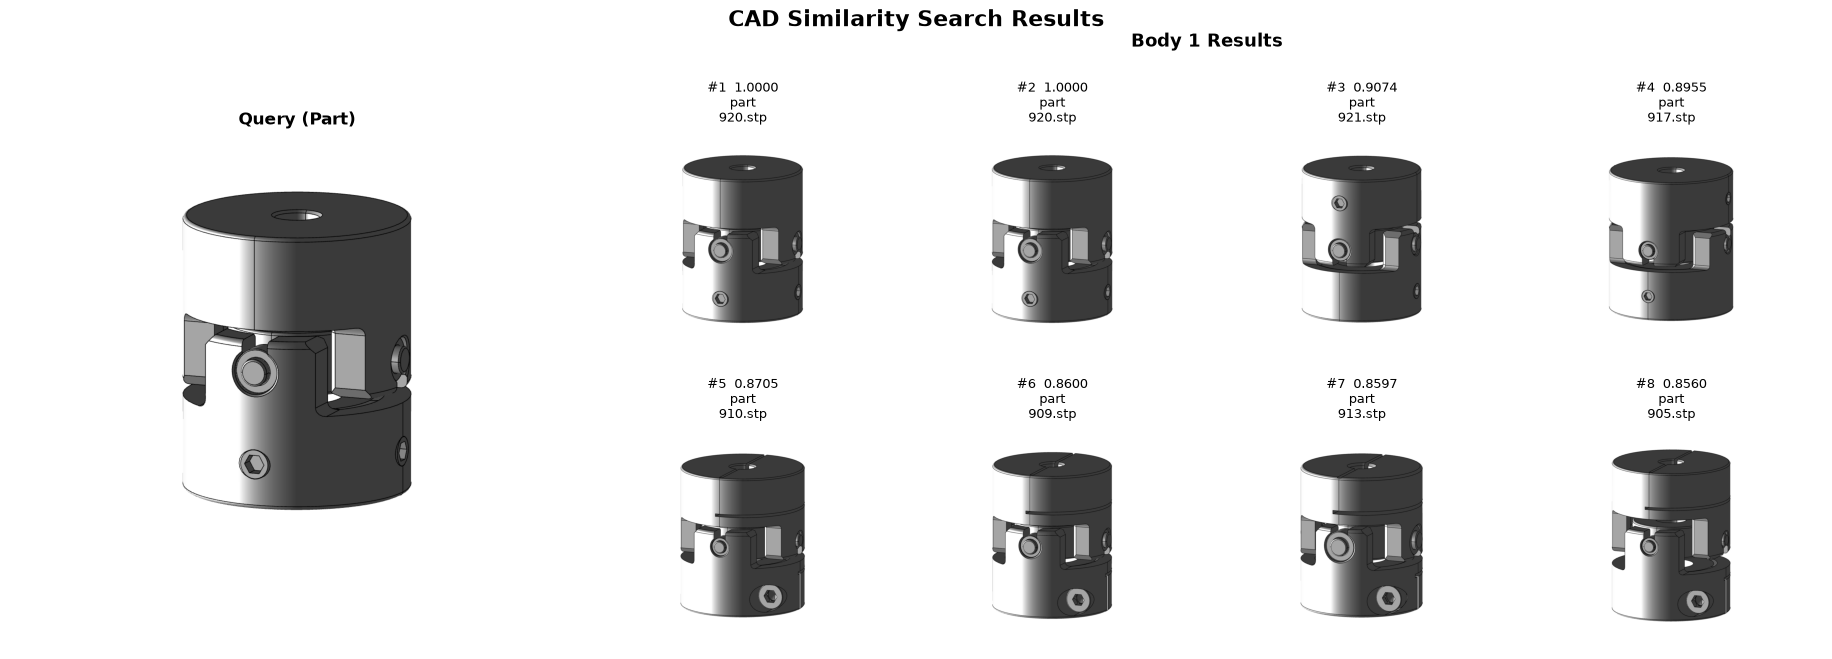

In [25]:
query_file = str(cad_files[17])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 0.291 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


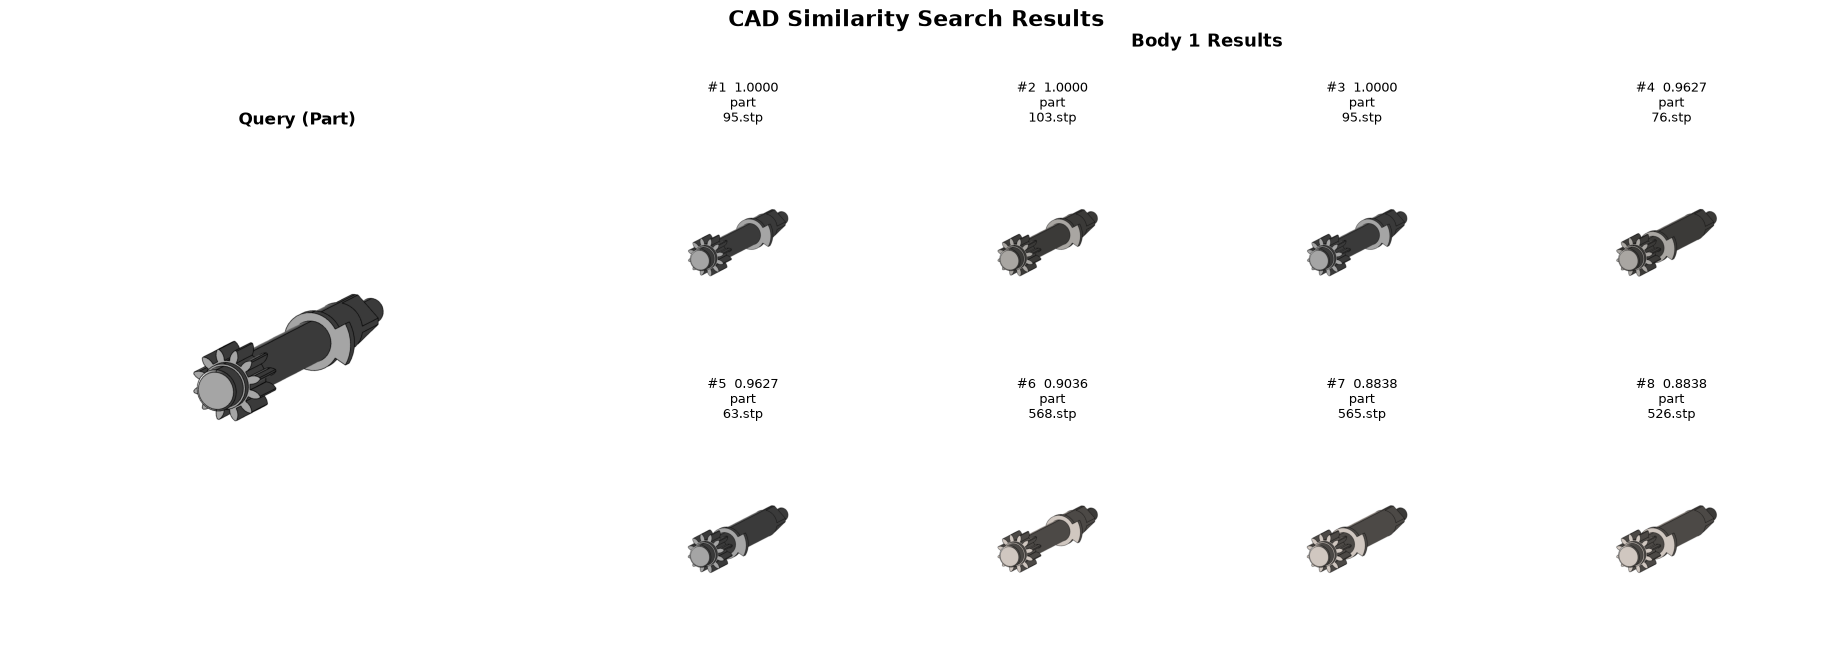

In [26]:
query_file = str(cad_files[18])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

Data Prep + Search similar files in dataset of 39736 files took 3.363 s
Reusing 8 existing PNGs and generating 0 PNGs using persistent process pool...


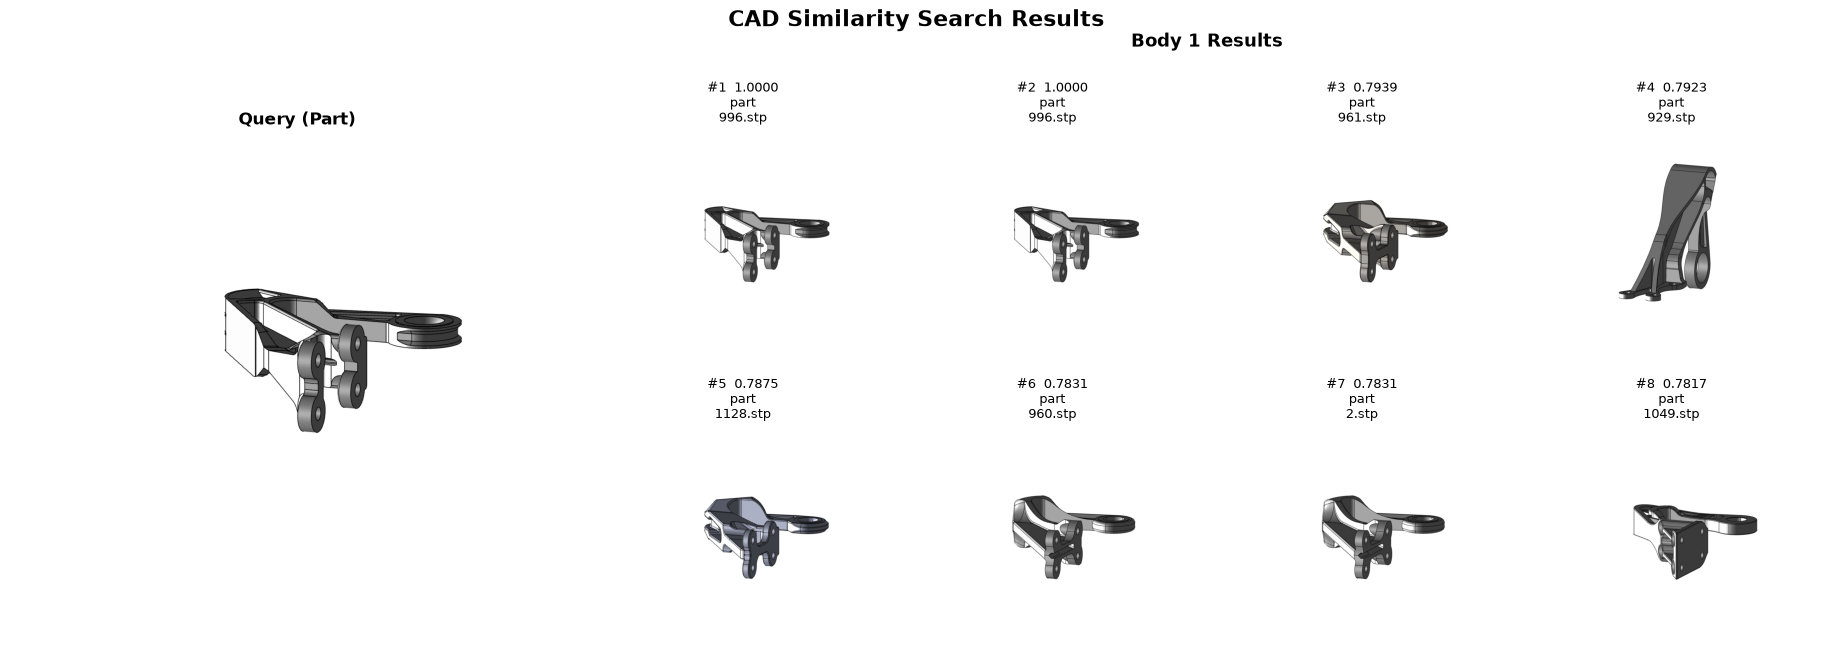

In [27]:
query_file = str(cad_files[19])

t0 = time.perf_counter()
hits = loaded_searcher.search_by_shape(query_file, top_k=8, filters={"kind": "part"} ) #

elapsed = time.perf_counter() - t0
print(f"Data Prep + Search similar files in dataset of {len(embeddingBatch.ids)} files took {elapsed:.3f} s")

ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=4)

## Production pattern and performance

### What takes time — and what doesn't

The timing output above reveals an important asymmetry:

- **B-rep encoding is the bottleneck.** Converting a CAD file into the tensor
  representation the model expects (face types, edge connectivity, surface normals,
  …) involves parsing the boundary representation and running the HOOPS Exchange
  conversion pipeline. This is the only step that touches the CAD file.
- **Vector search is near-instant.** Once both the query and the indexed parts are
  in embedding space, finding the top-K nearest neighbors in a 38 K-part FAISS index
  takes a few milliseconds regardless of index size (FAISS uses approximate nearest-
  neighbor algorithms that scale sub-linearly).

### Recommended production setup

In production, the database is indexed **once** and saved to a persistent file (`.faiss`
+ `.meta`). At query time only the incoming CAD file needs to be encoded:

```
┌────────────────────────────────────────────────────────┐
│  Offline (done once, or as new parts are added)        │
│                                                        │
│  CAD dataset  ──► B-rep encoder ──► FAISS index        │
│                                     (saved to disk)   │
└────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────┐
│  Online (per query)                                    │
│                                                        │
│  Query CAD file  ──► B-rep encoder  ──► embedding      │
│                                         │              │
│  Loaded FAISS index ◄──── search ◄──────┘              │
│       │                                                │
│       └──► top-K hits  (milliseconds)                  │
└────────────────────────────────────────────────────────┘
```

This is exactly what this notebook demonstrates: the index was built in
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb),
saved to disk, and loaded here with a single `load_shape_index` call.
`search_by_shape` then encodes only the query file before searching.

### Further reading

- **`CADSearch` API reference** — full parameter list, filter syntax, and batch
  search: <https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.CADSearch.html>
- **Embeddings in production** — indexing strategies, persistence, scaling, and
  integration patterns:
  <https://docs.techsoft3d.com/hoops/ai/programming_guide/embeddings-production.html>